# Week 36: operators in second quantization, Wick's theorems and the particle-hole formalism -- selected codes

**FYS4480/FYS9480, Quantum mechanics for many-particle systems**
Morten Hjorth-Jensen, Department of Physics and Center for Computing in Science Education, University of Oslo

This notebook accompanies the week-36 slides (`week36.tex`) and chapter 3 of the lecture notes (sections 3.1--3.4 and 3.11--3.16). As in week 35, every fermion creation and annihilation operator is an explicit matrix on the $2^n$ states of a small Fock space, so that every identity stated in the lectures -- the second-quantized operators, Wick's theorem and its generalisation *as operator identities*, the particle-hole decomposition of the Hamiltonian, the Condon-Slater rules -- can be verified as a matrix identity, to machine precision. The strategy is that of `BookPrograms/chapter03/wick.py`.

The sections follow the lectures:

1. Fermion operators as matrices, and the algebra (reminder)
2. Section 3.1: the dictionary between determinants and operator strings; the exterior power $U^{\wedge N}$
3. Sections 3.2--3.3: the number operator, one-body and two-body operators
4. Normal ordering and contractions (reminder)
5. Wick's theorem as an operator identity; the cost table
6. The generalised theorem as an operator identity; pairing counts
7. Applications: one- and two-body matrix elements between two-particle states
8. Section 3.16: Slater determinants as bit patterns
9. Section 3.4: the particle-hole formalism
10. The exercises of week 36: Condon-Slater rules and the density

In [3]:
import numpy as np
from itertools import combinations, permutations
from math import comb, factorial
np.set_printoptions(precision=6, suppress=True, linewidth=120)
rng = np.random.default_rng(2036)

## 1. Fermion operators as matrices in a finite Fock space (reminder)

A Slater determinant over $n$ single-particle states is encoded as an $n$-bit integer, bit $p$ set when orbital $p$ is occupied (section 8 makes this explicit). The annihilation operator $a_p$ clears bit $p$ and multiplies by $(-1)^{l}$, with $l$ the number of occupied orbitals with index below $p$ -- the creation operators $a_p$ has to pass. The creation operator is its transpose. Everything else in the notebook is built from these two matrices.

In [4]:
class FockSpace:
    '''Fermion creation/annihilation operators as matrices on 2^n Fock states.'''

    def __init__(self, n_orbitals):
        self.n = n_orbitals
        self.dim = 1 << n_orbitals
        self._a = [self._annihilate(p) for p in range(n_orbitals)]
        self._adag = [M.T.copy() for M in self._a]

    def _annihilate(self, p):
        M = np.zeros((self.dim, self.dim))
        for state in range(self.dim):
            if state & (1 << p):
                sign = (-1) ** bin(state & ((1 << p) - 1)).count("1")
                M[state ^ (1 << p), state] = sign
        return M

    def annihilate(self, p):
        return self._a[p]

    def create(self, p):
        return self._adag[p]

    def vacuum(self):
        v = np.zeros(self.dim)
        v[0] = 1.0
        return v

    def op(self, index, dagger):
        return self._adag[index] if dagger else self._a[index]

    def string(self, ops):
        '''Matrix of a product of operators; ops = [(index, dagger), ...], leftmost first.'''
        M = np.eye(self.dim)
        for index, dagger in ops:
            M = M @ self.op(index, dagger)
        return M

    def determinant(self, occupied):
        '''|p1 p2 ... pN> = a_p1^+ a_p2^+ ... a_pN^+ |0>, in the order given.'''
        v = self.vacuum()
        for p in reversed(occupied):
            v = self._adag[p] @ v
        return v


def anticommutator(A, B):
    return A @ B + B @ A


c = lambda p: (p, True)      # a_p^dagger
d = lambda p: (p, False)     # a_p

n = 4
space = FockSpace(n)
a = [space.annihilate(p) for p in range(n)]
adag = [space.create(p) for p in range(n)]
I = np.eye(space.dim)
vac = space.vacuum()

ok_cc = all(np.allclose(anticommutator(adag[p], adag[q]), 0) for p in range(n) for q in range(n))
ok_aa = all(np.allclose(anticommutator(a[p], a[q]), 0) for p in range(n) for q in range(n))
ok_mixed = all(np.allclose(anticommutator(adag[p], a[q]), (p == q) * I) for p in range(n) for q in range(n))
print(f"{{a_p^+, a_q^+}} = 0 for all p,q        : {ok_cc}")
print(f"{{a_p,   a_q  }} = 0 for all p,q        : {ok_aa}")
print(f"{{a_p^+, a_q  }} = delta_pq for all p,q : {ok_mixed}")
print(f"a_p |0> = 0 for all p                 : {all(np.allclose(a[p] @ vac, 0) for p in range(n))}")

{a_p^+, a_q^+} = 0 for all p,q        : True
{a_p,   a_q  } = 0 for all p,q        : True
{a_p^+, a_q  } = delta_pq for all p,q : True
a_p |0> = 0 for all p                 : True


## 2. Section 3.1: the dictionary, and the exterior power $U^{\wedge N}$

The overlap of two determinants is $\langle q_1\cdots q_N|p_1\cdots p_N\rangle=\det[\delta_{q_ip_j}]$: for ordered label sets this is $1$ when the sets coincide and $0$ otherwise, so the $\binom{n}{N}$ determinants are orthonormal and the map from first to second quantization is unitary with the identity as transformation matrix.

Between two *different* orbital bases, $\tilde a_\alpha^\dagger=\sum_p U_{p\alpha}a_p^\dagger$, the transformation matrix between the two determinant bases is the matrix of $N\times N$ minors of $U$,
$$\langle p_1\cdots p_N|\tilde\alpha_1\cdots\tilde\alpha_N\rangle=\det[U_{p_i\alpha_j}],$$
the $N$th exterior power $U^{\wedge N}$. Below we build $\tilde a^\dagger$ as matrices, form the rotated determinants explicitly, and compare their overlaps with the original determinants to the minors of $U$.

In [5]:
N = 2
subsets = list(combinations(range(n), N))          # ordered label sets p1 < p2 < ...
dets = {s: space.determinant(s) for s in subsets}

# orthonormality: <q1..qN|p1..pN> = det[delta_{q_i p_j}]
overlap = np.array([[dets[q] @ dets[p] for p in subsets] for q in subsets])
overlap_formula = np.array([[np.linalg.det(np.array([[float(qi == pj) for pj in p] for qi in q]))
                             for p in subsets] for q in subsets])
print("<q|p> = det[delta_{q_i p_j}] for all ordered label sets :", np.allclose(overlap, overlap_formula))
print("determinant basis orthonormal                        :", np.allclose(overlap, np.eye(len(subsets))))

# a random unitary U and the rotated creation operators
X = rng.normal(size=(n, n)) + 1j * rng.normal(size=(n, n))
U, _ = np.linalg.qr(X)
adag_tilde = [sum(U[p, alpha] * adag[p] for p in range(n)) for alpha in range(n)]
a_tilde = [M.conj().T for M in adag_tilde]
ok = all(np.allclose(anticommutator(a_tilde[al], adag_tilde[be]), (al == be) * I) for al in range(n) for be in range(n))
print("rotated operators obey {a~_alpha, a~_beta^+} = delta   :", ok)

def rotated_determinant(alphas):
    v = vac.astype(complex)
    for al in reversed(alphas):
        v = adag_tilde[al] @ v
    return v

T = np.array([[dets[p] @ rotated_determinant(al) for al in subsets] for p in subsets])   # <p|alpha~>
minors = np.array([[np.linalg.det(U[np.ix_(p, al)]) for al in subsets] for p in subsets])
print("<p1..pN|alpha~1..alpha~N> = det[U_{p_i alpha_j}] (all minors):", np.allclose(T, minors))
print("U^(wedge N) is unitary                                     :", np.allclose(T.conj().T @ T, np.eye(len(subsets))))
print(f"size of U^(wedge N): {len(subsets)} x {len(subsets)} = C({n},{N})^2")

# mixing only the occupied orbitals: a single minor, det U_occ, i.e. a phase
occ = (0, 1)
V, _ = np.linalg.qr(rng.normal(size=(N, N)) + 1j * rng.normal(size=(N, N)))
Ufull = np.eye(n, dtype=complex); Ufull[np.ix_(occ, occ)] = V
adag_rot = [sum(Ufull[p, al] * adag[p] for p in range(n)) for al in range(n)]
v = vac.astype(complex)
for al in reversed(occ):
    v = adag_rot[al] @ v
print("rotation among occupied orbitals: |Phi~> = det(U_occ) |Phi>   :",
      np.allclose(v, np.linalg.det(V) * dets[occ]), "  |det U_occ| =", abs(np.linalg.det(V)).round(6))

<q|p> = det[delta_{q_i p_j}] for all ordered label sets : True
determinant basis orthonormal                        : True
rotated operators obey {a~_alpha, a~_beta^+} = delta   : True
<p1..pN|alpha~1..alpha~N> = det[U_{p_i alpha_j}] (all minors): True
U^(wedge N) is unitary                                     : True
size of U^(wedge N): 6 x 6 = C(4,2)^2
rotation among occupied orbitals: |Phi~> = det(U_occ) |Phi>   : True   |det U_occ| = 1.0


## 3. Sections 3.2--3.3: the number operator, one-body and two-body operators

$$\hat N=\sum_p a_p^\dagger a_p,\qquad
\hat H_0=\sum_{pq}\langle p|\hat h_0|q\rangle a_p^\dagger a_q,\qquad
\hat H_I=\tfrac12\sum_{pqrs}\langle pq|\hat v|rs\rangle a_p^\dagger a_q^\dagger a_s a_r
=\tfrac14\sum_{pqrs}\langle pq|\hat v|rs\rangle_{\rm AS}\,a_p^\dagger a_q^\dagger a_s a_r .$$

We draw random Hermitian one-body elements and random two-body elements with the symmetry $\langle pq|v|rs\rangle=\langle qp|v|sr\rangle$ (and real, symmetric under bra--ket exchange), build the operators as matrices and check the statements of Thursday's lecture: $\hat N$ has integer eigenvalues, $[\hat N,\hat H]=0$, the $\frac12$- and $\frac14$-forms agree, $\langle\alpha_1|\hat H_0|\alpha_2\rangle=\langle\alpha_1|\hat h_0|\alpha_2\rangle$, $\langle\alpha_1\alpha_2|\hat H_I|\beta_1\beta_2\rangle=\langle\alpha_1\alpha_2|\hat v|\beta_1\beta_2\rangle_{\rm AS}$, and the sign flip when the annihilation operators are written in the wrong order (pause #2).

In [6]:
def random_onebody(n):
    h = rng.normal(size=(n, n))
    return (h + h.T) / 2

def random_twobody(n):
    '''<pq|v|rs> real, with <pq|v|rs> = <qp|v|sr> = <rs|v|pq>.'''
    v = rng.normal(size=(n, n, n, n))
    v = v + v.transpose(1, 0, 3, 2)          # <pq|v|rs> = <qp|v|sr>
    v = v + v.transpose(2, 3, 0, 1)          # Hermitian (real): <pq|v|rs> = <rs|v|pq>
    return v

def antisymmetrise(v):
    return v - v.transpose(0, 1, 3, 2)       # <pq|v|rs>_AS = <pq|v|rs> - <pq|v|sr>

def onebody_operator(space, h):
    n = space.n
    return sum(h[p, q] * space.create(p) @ space.annihilate(q) for p in range(n) for q in range(n))

def twobody_operator(space, v, antisymmetrised=False, reversed_order=True):
    n = space.n
    factor = 0.25 if antisymmetrised else 0.5
    H = np.zeros((space.dim, space.dim))
    for p in range(n):
        for q in range(n):
            cc = space.create(p) @ space.create(q)
            for r in range(n):
                for s in range(n):
                    aa = space.annihilate(s) @ space.annihilate(r) if reversed_order \
                         else space.annihilate(r) @ space.annihilate(s)
                    H += factor * v[p, q, r, s] * cc @ aa
    return H

h0 = random_onebody(n)
v = random_twobody(n)
vAS = antisymmetrise(v)

Nhat = sum(adag[p] @ a[p] for p in range(n))
H0 = onebody_operator(space, h0)
HI_half = twobody_operator(space, v)
HI_quarter = twobody_operator(space, vAS, antisymmetrised=True)
H = H0 + HI_quarter

print("eigenvalues of N                          :", np.unique(np.round(np.linalg.eigvalsh(Nhat), 8)))
print("[N, H0] = 0, [N, H_I] = 0                 :", np.allclose(Nhat @ H0, H0 @ Nhat), np.allclose(Nhat @ H, H @ Nhat))
print("1/2-form with plain v == 1/4-form with v_AS:", np.allclose(HI_half, HI_quarter))
print("[N, a_p^+] = a_p^+ and [N, a_p] = -a_p    :",
      all(np.allclose(Nhat @ adag[p] - adag[p] @ Nhat, adag[p]) and np.allclose(Nhat @ a[p] - a[p] @ Nhat, -a[p]) for p in range(n)))

# <alpha1| H0 |alpha2> = <alpha1| h0 |alpha2>
single = [adag[p] @ vac for p in range(n)]
H0_1p = np.array([[single[p] @ H0 @ single[q] for q in range(n)] for p in range(n)])
print("<alpha1|H0|alpha2> = <alpha1|h0|alpha2>   :", np.allclose(H0_1p, h0))

# <alpha1 alpha2| H_I |beta1 beta2> = <alpha1 alpha2|v|beta1 beta2>_AS
pairs = list(combinations(range(n), 2))
two = {pq: space.determinant(pq) for pq in pairs}
HI_2p = np.array([[two[ab] @ HI_half @ two[cd] for cd in pairs] for ab in pairs])
vAS_2p = np.array([[vAS[ab[0], ab[1], cd[0], cd[1]] for cd in pairs] for ab in pairs])
print("<a1a2|H_I|b1b2> = <a1a2|v|b1b2>_AS         :", np.allclose(HI_2p, vAS_2p))

# pause #2: the wrong operator order a_r a_s flips every sign
HI_wrong = twobody_operator(space, v, reversed_order=False)
print("wrong order a_gamma a_delta gives -H_I    :", np.allclose(HI_wrong, -HI_half))

eigenvalues of N                          : [0. 1. 2. 3. 4.]
[N, H0] = 0, [N, H_I] = 0                 : True True
1/2-form with plain v == 1/4-form with v_AS: True
[N, a_p^+] = a_p^+ and [N, a_p] = -a_p    : True
<alpha1|H0|alpha2> = <alpha1|h0|alpha2>   : True
<a1a2|H_I|b1b2> = <a1a2|v|b1b2>_AS         : True
wrong order a_gamma a_delta gives -H_I    : True


## 4. Normal ordering and contractions (reminder)

`normal_order` returns the sign $(-1)^\kappa$ and the reordered string (creation operators first, relative orders kept). The contraction is $xy-N[xy]=\langle0|xy|0\rangle$; only $a_pa_q^\dagger\to\delta_{pq}$ survives.

In [7]:
def normal_order(ops):
    '''(sign, reordered): creation operators first, relative orders kept.'''
    creators = [o for o in ops if o[1]]
    annihilators = [o for o in ops if not o[1]]
    swaps = sum(1 for i, o in enumerate(ops) if not o[1] for p in ops[i + 1:] if p[1])
    return (-1) ** swaps, tuple(creators + annihilators)

def normal_product(space, ops):
    sign, reordered = normal_order(ops)
    return sign * space.string(reordered)

def contraction_value(x, y):
    '''<0| x y |0>: only a_p a_q^dagger with p == q survives.'''
    return 1.0 if (not x[1]) and y[1] and x[0] == y[0] else 0.0

ok = True
for _ in range(200):
    ops = [(int(rng.integers(0, n)), bool(rng.integers(0, 2))) for _ in range(int(rng.integers(1, 7)))]
    ok &= np.isclose(vac @ normal_product(space, ops) @ vac, 0)
print("<0|N[any non-empty string]|0> = 0                :", ok)

ok = True
for x in [c(p) for p in range(n)] + [d(p) for p in range(n)]:
    for y in [c(p) for p in range(n)] + [d(p) for p in range(n)]:
        ok &= np.allclose(space.string([x, y]) - normal_product(space, [x, y]), contraction_value(x, y) * I)
print("x y - N[x y] = contraction * identity, all pairs  :", ok)

<0|N[any non-empty string]|0> = 0                : True
x y - N[x y] = contraction * identity, all pairs  : True


## 5. Wick's theorem as an operator identity

The theorem says
$$xyz\cdots w=N[xyz\cdots w]+\sum_{(1)}N[\cdots]+\sum_{(2)}N[\cdots]+\cdots,$$
where a term with $m$ contracted pairs is $(-1)^{P}\times\prod(\text{contractions})\times N[\text{uncontracted operators}]$, and $(-1)^P$ is the parity of the permutation that brings the contracted pairs, each in its original order, to the front of the string. (For the fully contracted terms this is the crossing sign $(-1)^\nu$ of the slides.) The function `wick_operator` sums over **all partial matchings** and returns a matrix; we compare it with the plain product for random strings of up to eight operators. Then we restrict to the vacuum expectation value and reproduce last week's cost table.

In [8]:
def partial_matchings(indices):
    '''All sets of disjoint pairs (including the empty set) drawn from indices.'''
    if not indices:
        yield []
        return
    first, rest = indices[0], indices[1:]
    for tail in partial_matchings(rest):            # first stays uncontracted
        yield tail
    for k in range(len(rest)):                      # first is paired with rest[k]
        for tail in partial_matchings(rest[:k] + rest[k + 1:]):
            yield [(first, rest[k])] + tail

def perfect_matchings(indices):
    for m in partial_matchings(indices):
        if 2 * len(m) == len(indices):
            yield m

def permutation_parity(perm):
    '''Parity of a permutation given as a list of positions.'''
    perm = list(perm); parity = 0
    for i in range(len(perm)):
        while perm[i] != i:
            j = perm[i]; perm[i], perm[j] = perm[j], perm[i]; parity ^= 1
    return -1 if parity else 1

def matching_sign(pairs):
    '''(-1)^(number of crossings), for a complete pairing.'''
    crossings = sum(1 for (A, B), (C, D) in combinations(pairs, 2) if A < C < B < D or C < A < D < B)
    return (-1) ** crossings

def wick_operator(space, ops):
    '''Right-hand side of Wick's theorem as a matrix: all partial contractions.'''
    ops = tuple(ops); M = len(ops)
    total = np.zeros((space.dim, space.dim))
    for pairs in partial_matchings(list(range(M))):
        value = 1.0
        for A, B in pairs:
            value *= contraction_value(ops[A], ops[B])
            if value == 0.0:
                break
        if value == 0.0:
            continue
        contracted = [i for pair in pairs for i in pair]
        rest = [i for i in range(M) if i not in contracted]
        sign = permutation_parity(contracted + rest)
        total += sign * value * normal_product(space, [ops[i] for i in rest])
    return total

def vev_wick(ops):
    ops = tuple(ops)
    if len(ops) % 2:
        return 0.0
    total = 0.0
    for pairs in perfect_matchings(list(range(len(ops)))):
        value = 1.0
        for A, B in pairs:
            value *= contraction_value(ops[A], ops[B])
            if value == 0.0:
                break
        total += matching_sign(pairs) * value
    return total

ok, tested = True, 0
for _ in range(150):
    ops = [(int(rng.integers(0, n)), bool(rng.integers(0, 2))) for _ in range(int(rng.integers(2, 9)))]
    ok &= np.allclose(space.string(ops), wick_operator(space, ops))
    tested += 1
print(f"product == N[...] + all contractions, as matrices, {tested} random strings (M = 2..8): {ok}")

ok = all(np.isclose(vev_wick(ops), vac @ space.string(ops) @ vac)
         for ops in [[(int(rng.integers(0, n)), bool(rng.integers(0, 2))) for _ in range(int(rng.integers(2, 9)))]
                     for _ in range(300)])
print(f"vacuum expectation value: pairings == matrices, 300 random strings           : {ok}")

# the three-operator expansion of the slides: a_p a_q a_r^+ = N[...] + d_qr a_p - d_pr a_q
p, q, r = 0, 1, 1
lhs = space.string([d(p), d(q), c(r)])
rhs = normal_product(space, [d(p), d(q), c(r)]) + (q == r) * a[p] - (p == r) * a[q]
print("a_p a_q a_r^+ = N[a_p a_q a_r^+] + d_qr a_p - d_pr a_q                       :", np.allclose(lhs, rhs))

product == N[...] + all contractions, as matrices, 150 random strings (M = 2..8): True
vacuum expectation value: pairings == matrices, 300 random strings           : True
a_p a_q a_r^+ = N[a_p a_q a_r^+] + d_qr a_p - d_pr a_q                       : True


vacuum expectation value: pairings == matrices, 300 random strings           : True


a_p a_q a_r^+ = N[a_p a_q a_r^+] + d_qr a_p - d_pr a_q                       : True


In [9]:
# the cost table of the slides: n annihilation operators followed by n creation operators,
# with symbolic (all-distinct) indices, as in wick.py
calls = [0]

def brute_force_calls(ops):
    '''Count the recursive calls of the anticommutation route (symbolic indices).'''
    ops = tuple(ops)
    calls[0] += 1
    if len(ops) == 0 or len(ops) % 2 == 1:
        return
    if ops[0][1] or not ops[-1][1]:      # starts with a^+, or ends with a
        return
    for k in range(len(ops) - 1):
        left, right = ops[k], ops[k + 1]
        if not left[1] and right[1]:     # a_p a_q^dagger found
            brute_force_calls(ops[:k] + ops[k + 2:])                  # delta term
            brute_force_calls(ops[:k] + (right, left) + ops[k + 2:])  # swap
            return

def double_factorial(m):
    return 1 if m <= 0 else m * double_factorial(m - 2)

print(f"{'M':>4} {'pairings (M-1)!!':>18} {'recursive calls':>16} {'survivors n!':>13}")
for nn in [1, 2, 3, 4, 5]:
    ops = [(f"x{k}", False) for k in range(nn)] + [(f"y{k}", True) for k in range(nn)]
    survivors = sum(1 for pairs in perfect_matchings(list(range(2 * nn)))
                    if all((not ops[A][1]) and ops[B][1] for A, B in pairs))
    calls[0] = 0
    brute_force_calls(ops)
    print(f"{2*nn:>4} {double_factorial(2*nn-1):>18} {calls[0]:>16} {survivors:>13}")

   M   pairings (M-1)!!  recursive calls  survivors n!
   2                  1                3             1
   4                  3                9             2
   6                 15               31             6
   8                105              129            24
  10                945              651           120


## 6. The generalised theorem as an operator identity

For a product of normal-ordered groups only the **inter-group** contractions appear:
$$N[A_1A_2\cdots]\,N[B_1B_2\cdots]\,N[C_1C_2\cdots]=N[A_1A_2\cdots B_1B_2\cdots C_1C_2\cdots]+\sum_{\text{inter-group}}N[\cdots].$$
We build random groups, normal-order each (with its sign), multiply the normal-ordered groups as matrices, and compare with the sum over partial matchings restricted to pairs joining different groups. We also count the pairings quoted on the slides: $15\to8$, $105\to24$, $10\,395\to1\,728$.

In [10]:
def wick_generalised(space, groups):
    '''RHS of the generalised theorem: groups is a list of operator lists, each already normal-ordered.'''
    ops = tuple(o for g in groups for o in g)
    label = [gi for gi, g in enumerate(groups) for _ in g]
    M = len(ops)
    total = np.zeros((space.dim, space.dim))
    for pairs in partial_matchings(list(range(M))):
        if any(label[A] == label[B] for A, B in pairs):
            continue                                   # no line inside a group
        value = 1.0
        for A, B in pairs:
            value *= contraction_value(ops[A], ops[B])
            if value == 0.0:
                break
        if value == 0.0:
            continue
        contracted = [i for pair in pairs for i in pair]
        rest = [i for i in range(M) if i not in contracted]
        total += permutation_parity(contracted + rest) * value * normal_product(space, [ops[i] for i in rest])
    return total

def random_group(size):
    ops = [(int(rng.integers(0, n)), bool(rng.integers(0, 2))) for _ in range(size)]
    sign, reordered = normal_order(ops)
    return list(reordered)                # written in normal-ordered form

ok = True
for ngroups in [2, 3, 4]:
    for _ in range(20):
        groups = [random_group(int(rng.integers(1, 4))) for _ in range(ngroups)]
        lhs = np.eye(space.dim)
        for g in groups:
            lhs = lhs @ space.string(g)               # each group is its own normal product
        ok &= np.allclose(lhs, wick_generalised(space, groups))
    print(f"generalised theorem as an operator identity, {ngroups} groups: {ok}")

def count_pairings(sizes):
    label = [gi for gi, s in enumerate(sizes) for _ in range(s)]
    total = inter = 0
    for pairs in perfect_matchings(list(range(sum(sizes)))):
        total += 1
        inter += all(label[A] != label[B] for A, B in pairs)
    return total, inter

for sizes in [(2, 2, 2), (2, 4, 2), (4, 4, 4)]:
    total, inter = count_pairings(sizes)
    print(f"groups {sizes}: {total:>6} pairings, {inter:>5} between different groups  (fraction {inter/total:.3f})")

generalised theorem as an operator identity, 2 groups: True
generalised theorem as an operator identity, 3 groups: True
generalised theorem as an operator identity, 4 groups: True
groups (2, 2, 2):     15 pairings,     8 between different groups  (fraction 0.533)
groups (2, 4, 2):    105 pairings,    24 between different groups  (fraction 0.229)
groups (4, 4, 4):  10395 pairings,  1728 between different groups  (fraction 0.166)


generalised theorem as an operator identity, 4 groups: True
groups (2, 2, 2):     15 pairings,     8 between different groups  (fraction 0.533)
groups (2, 4, 2):    105 pairings,    24 between different groups  (fraction 0.229)


groups (4, 4, 4):  10395 pairings,  1728 between different groups  (fraction 0.166)


## 7. Applications: matrix elements between two-particle states (section 3.15)

The one-body result
$$\langle ij|\hat O^{(1)}|k\ell\rangle=\delta_{j\ell}\langle i|o|k\rangle-\delta_{jk}\langle i|o|\ell\rangle-\delta_{i\ell}\langle j|o|k\rangle+\delta_{ik}\langle j|o|\ell\rangle$$
and the two-body result $\langle k\ell|\hat H_I|ij\rangle=\langle k\ell|v|ij\rangle_{\rm AS}$ are checked three ways: matrices, the ordinary Wick theorem (all $105$ pairings), and the generalised theorem (inter-group pairings only). For the two-body element we also list which of the $(p,q,r,s)$ assignments survive -- four, as on the slides.

In [11]:
def onebody_formula(h, i, j, k, l):
    return (j == l) * h[i, k] - (j == k) * h[i, l] - (i == l) * h[j, k] + (i == k) * h[j, l]

# one-body: all (ij), (kl) with i != j, k != l, by matrices vs formula
ok = True
for (i, j) in permutations(range(n), 2):
    for (k, l) in permutations(range(n), 2):
        bra = space.determinant((i, j)); ket = space.determinant((k, l))
        ok &= np.isclose(bra @ H0 @ ket, onebody_formula(h0, i, j, k, l))
print("<ij|O1|kl> four-term formula == matrices, all index choices:", ok)

# one matrix element, three ways
i, j, k, l = 0, 1, 0, 2
by_matrix = space.determinant((i, j)) @ H0 @ space.determinant((k, l))
by_wick = sum(h0[p, q] * vev_wick([d(j), d(i), c(p), d(q), c(k), c(l)]) for p in range(n) for q in range(n))
by_general = sum(h0[p, q] * (vac @ wick_generalised(space, [[d(j), d(i)], [c(p), d(q)], [c(k), c(l)]]) @ vac)
                 for p in range(n) for q in range(n))
print(f"<{i}{j}|O1|{k}{l}>: matrices {by_matrix:.6f}, Wick {by_wick:.6f}, generalised {by_general:.6f}, formula {onebody_formula(h0, i, j, k, l):.6f}")

# two-body: <kl|H_I|ij> = <kl|v|ij>_AS for all pairs, and the surviving (p,q,r,s) assignments for one element
ok = all(np.isclose(space.determinant(kl) @ HI_half @ space.determinant(ij), vAS[kl[0], kl[1], ij[0], ij[1]])
         for kl in pairs for ij in pairs)
print("<kl|H_I|ij> = <kl|v|ij>_AS, all pairs                    :", ok)

i, j = 0, 1
survivors = [(p, q, r, s) for p in range(n) for q in range(n) for r in range(n) for s in range(n)
             if vev_wick([d(j), d(i), c(p), c(q), d(s), d(r), c(i), c(j)]) != 0.0]
print(f"<{i}{j}|H_I|{i}{j}>: surviving (p,q,r,s) assignments out of {n**4}:", survivors)
total = sum(0.5 * v[p, q, r, s] * vev_wick([d(j), d(i), c(p), c(q), d(s), d(r), c(i), c(j)]) for p, q, r, s in survivors)
print(f"   sum of the four terms = {total:.6f},  <ij|v|ij> - <ij|v|ji> = {v[i,j,i,j] - v[i,j,j,i]:.6f}")

<ij|O1|kl> four-term formula == matrices, all index choices: True
<01|O1|02>: matrices 0.059038, Wick 0.059038, generalised 0.059038, formula 0.059038
<kl|H_I|ij> = <kl|v|ij>_AS, all pairs                    : True
<01|H_I|01>: surviving (p,q,r,s) assignments out of 256: [(0, 1, 0, 1), (0, 1, 1, 0), (1, 0, 0, 1), (1, 0, 1, 0)]
   sum of the four terms = -4.955652,  <ij|v|ij> - <ij|v|ji> = -4.955652


<01|H_I|01>: surviving (p,q,r,s) assignments out of 256: [(0, 1, 0, 1), (0, 1, 1, 0), (1, 0, 0, 1), (1, 0, 1, 0)]
   sum of the four terms = -4.955652,  <ij|v|ij> - <ij|v|ji> = -4.955652


## 8. Section 3.16: Slater determinants as bit patterns

A determinant is an integer; $a_p^\dagger$ sets bit $p$ (null vector if already set) with the phase $(-1)^{l}$, $l$ the number of occupied orbitals below $p$; $a_p$ clears it with the same phase. The pair move $a_j^\dagger a_i$ has phase $(-1)^{\#\{\text{occupied strictly between } i \text{ and } j\}}$, obtained from a bit mask and a popcount. Everything is compared with the Fock-space matrices, state by state -- and finally $\hat H|\Phi\rangle$ is computed with bit operations only and compared with the matrix--vector product.

In [12]:
def bits(state, n):
    '''Book notation: alpha_0 leftmost.'''
    return "|" + "".join(str((state >> p) & 1) for p in range(n)) + ">"

def create_bit(state, p):
    if (state >> p) & 1:
        return 0, None
    phase = -1 if bin(state & ((1 << p) - 1)).count("1") % 2 else 1
    return phase, state | (1 << p)

def annihilate_bit(state, p):
    if not (state >> p) & 1:
        return 0, None
    phase = -1 if bin(state & ((1 << p) - 1)).count("1") % 2 else 1
    return phase, state & ~(1 << p)

def move(state, i, j):
    '''a_j^dagger a_i acting on a bit pattern: (phase, new_state) or (0, None).'''
    if not (state >> i) & 1:
        return 0, None                       # orbital i empty
    if i == j:
        return 1, state                      # a_i^dagger a_i counts the occupation
    if (state >> j) & 1:
        return 0, None                       # orbital j already occupied
    lo, hi = min(i, j), max(i, j)
    between = state & ((1 << hi) - (1 << (lo + 1)))
    phase = -1 if bin(between).count("1") % 2 else 1
    return phase, (state & ~(1 << i)) | (1 << j)

# the examples of the book and the slides: n = 16, particles in 3, 6, 10, 13
state = (1 << 3) | (1 << 6) | (1 << 10) | (1 << 13)
print("Phi_{3,6,10,13} =", bits(state, 16), "=", state)
ph, new = create_bit(state, 4);  print("a_4^+ Phi =", ph, bits(new, 16))
ph, new = create_bit(state, 6);  print("a_6^+ Phi =", ph, "(null vector)")
print("dim H for n = 16, N = 4:", comb(16, 4))

print("\na_2^+ on the five-bit patterns of the slides:")
for s in [0b11100, 0b11010, 0b10110, 0b01110, 0b11001, 0b10101, 0b01101, 0b10011, 0b01011]:
    ph, new = create_bit(s, 2)
    print(f"  a_2^+ {bits(s,5)} = {ph:+d} x {bits(new,5) if new is not None else bits(s,5)}" if ph else
          f"  a_2^+ {bits(s,5)} =  0")

# compare with the matrices for every state of the small space
ok = True
for s in range(space.dim):
    for p in range(n):
        ph, new = create_bit(s, p)
        col = adag[p][:, s]
        ok &= (np.allclose(col, 0) if ph == 0 else (col[new] == ph and np.count_nonzero(col) == 1))
        ph, new = annihilate_bit(s, p)
        col = a[p][:, s]
        ok &= (np.allclose(col, 0) if ph == 0 else (col[new] == ph and np.count_nonzero(col) == 1))
        for q in range(n):
            ph, new = move(s, p, q)
            col = (adag[q] @ a[p])[:, s]
            ok &= (np.allclose(col, 0) if ph == 0 else (col[new] == ph and np.count_nonzero(col) == 1))
print("\nbit operations == Fock-space matrices for a^+, a and a_j^+ a_i, every state and index:", ok)

# H |Phi> by bit operations only
def apply_hamiltonian_bits(state, h, vAS):
    '''Return {new_state: amplitude} for H = sum h_pq a_p^+ a_q + 1/4 sum vAS_pqrs a_p^+ a_q^+ a_s a_r.'''
    out = {}
    nn = h.shape[0]
    for q in range(nn):
        for p in range(nn):
            ph, new = move(state, q, p)
            if ph:
                out[new] = out.get(new, 0.0) + ph * h[p, q]
    for r in range(nn):
        ph1, s1 = annihilate_bit(state, r)
        if not ph1: continue
        for s in range(nn):
            ph2, s2 = annihilate_bit(s1, s)
            if not ph2: continue
            for q in range(nn):
                ph3, s3 = create_bit(s2, q)
                if not ph3: continue
                for p in range(nn):
                    ph4, s4 = create_bit(s3, p)
                    if not ph4: continue
                    out[s4] = out.get(s4, 0.0) + 0.25 * vAS[p, q, r, s] * ph1 * ph2 * ph3 * ph4
    return out

ok = True
for state in range(space.dim):
    vec = np.zeros(space.dim)
    for new, amp in apply_hamiltonian_bits(state, h0, vAS).items():
        vec[new] += amp
    ok &= np.allclose(vec, H[:, state])
print("H|Phi> by bit operations == matrix column, every determinant                           :", ok)

Phi_{3,6,10,13} = |0001001000100100> = 9288
a_4^+ Phi = -1 |0001101000100100>
a_6^+ Phi = 0 (null vector)
dim H for n = 16, N = 4: 1820

a_2^+ on the five-bit patterns of the slides:
  a_2^+ |00111> =  0
  a_2^+ |01011> = -1 x |01111>
  a_2^+ |01101> =  0
  a_2^+ |01110> =  0
  a_2^+ |10011> = -1 x |10111>
  a_2^+ |10101> =  0
  a_2^+ |10110> =  0
  a_2^+ |11001> = +1 x |11101>
  a_2^+ |11010> = +1 x |11110>

bit operations == Fock-space matrices for a^+, a and a_j^+ a_i, every state and index: True
H|Phi> by bit operations == matrix column, every determinant                           : True


## 9. Section 3.4: the particle-hole formalism

We take a larger space, $n=6$ orbitals, fill the lowest $n_c=3$ as the reference $|c\rangle$ (Fermi level $F=2$), and define
$$b_\alpha^\dagger=\begin{cases}a_\alpha^\dagger&\alpha>F\\ a_\alpha&\alpha\le F\end{cases}\qquad
b_\alpha=\begin{cases}a_\alpha&\alpha>F\\ a_\alpha^\dagger&\alpha\le F.\end{cases}$$
We check $b_\alpha|c\rangle=0$, the anticommutation relations, the two number operators, and then the particle-hole forms of $\hat H_0$ and of the **five groups** of $\hat H_I$ exactly as written on the slides, as matrix identities. Finally the reference energy and the two Fermi-vacuum contractions.

In [13]:
n6 = 6
S = FockSpace(n6)
A = [S.annihilate(p) for p in range(n6)]
Ad = [S.create(p) for p in range(n6)]
I6 = np.eye(S.dim)
holes = [0, 1, 2]                    # i, j, k, l  (<= F)
parts = [3, 4, 5]                    # a, b, c, d  (> F)
core = S.determinant(holes)          # |c> = a_0^+ a_1^+ a_2^+ |0>
n_c = len(holes)

B = [A[p] if p in parts else Ad[p] for p in range(n6)]      # b_alpha
Bd = [Ad[p] if p in parts else A[p] for p in range(n6)]     # b_alpha^dagger

print("<c|c> = 1                                  :", np.isclose(core @ core, 1))
print("b_alpha |c> = 0 for all alpha              :", all(np.allclose(B[p] @ core, 0) for p in range(n6)))
print("a_i |c> != 0 for holes                     :", all(not np.allclose(A[i] @ core, 0) for i in holes))
print("{b_alpha^+, b_beta} = delta                :", all(np.allclose(anticommutator(Bd[p], B[q]), (p == q) * I6) for p in range(n6) for q in range(n6)))
print("{b^+, b^+} = {b, b} = 0                    :", all(np.allclose(anticommutator(Bd[p], Bd[q]), 0) and np.allclose(anticommutator(B[p], B[q]), 0) for p in range(n6) for q in range(n6)))

# number operators
N6 = sum(Ad[p] @ A[p] for p in range(n6))
N_ph = sum(Bd[a_] @ B[a_] for a_ in parts) + n_c * I6 - sum(Bd[i] @ B[i] for i in holes)
Nqp = sum(Bd[p] @ B[p] for p in range(n6))
print("N = sum_a b^+b + n_c - sum_i b^+b          :", np.allclose(N6, N_ph))
state_2p2h = Bd[3] @ Bd[4] @ Bd[0] @ Bd[1] @ core      # |a b i^-1 j^-1>
print("2p2h state: N =", (state_2p2h @ N6 @ state_2p2h).round(6), "  N_qp =", (state_2p2h @ Nqp @ state_2p2h).round(6))
state_1p = Bd[5] @ core
print("1p state  : N =", (state_1p @ N6 @ state_1p).round(6), "  N_qp =", (state_1p @ Nqp @ state_1p).round(6))

<c|c> = 1                                  : True
b_alpha |c> = 0 for all alpha              : True
a_i |c> != 0 for holes                     : True
{b_alpha^+, b_beta} = delta                : True
{b^+, b^+} = {b, b} = 0                    : True
N = sum_a b^+b + n_c - sum_i b^+b          : True
2p2h state: N = 3.0   N_qp = 4.0
1p state  : N = 4.0   N_qp = 1.0


In [14]:
h6 = random_onebody(n6)
v6 = antisymmetrise(random_twobody(n6))          # antisymmetrised elements throughout

H0_6 = onebody_operator(S, h6)
HI_6 = twobody_operator(S, v6, antisymmetrised=True)

# ---- H0 in particle-hole form (slide "The one-body operator in particle-hole form")
H0_ph = (sum(h6[a_, b_] * Bd[a_] @ B[b_] for a_ in parts for b_ in parts)
         + sum(h6[a_, i] * Bd[a_] @ Bd[i] + h6[i, a_] * B[i] @ B[a_] for a_ in parts for i in holes)
         + sum(h6[i, i] for i in holes) * I6
         - sum(h6[j, i] * Bd[i] @ B[j] for i in holes for j in holes))
print("H0 == particle-hole form                   :", np.allclose(H0_6, H0_ph))

# ---- H_I in particle-hole form: the five groups of the slides
P, Hh = parts, holes
def bb(*ops):
    M = np.eye(S.dim)
    for o in ops:
        M = M @ o
    return M

HIa = 0.25 * sum(v6[a_, b_, c_, d_] * bb(Bd[a_], Bd[b_], B[d_], B[c_]) for a_ in P for b_ in P for c_ in P for d_ in P)

HIb = 0.5 * sum(v6[a_, b_, c_, i] * bb(Bd[a_], Bd[b_], Bd[i], B[c_]) + v6[c_, i, a_, b_] * bb(Bd[c_], B[i], B[b_], B[a_])
                for a_ in P for b_ in P for c_ in P for i in Hh)

HIc = (0.25 * sum(v6[a_, b_, i, j] * bb(Bd[a_], Bd[b_], Bd[j], Bd[i]) + v6[i, j, a_, b_] * bb(B[i], B[j], B[b_], B[a_])
                  for a_ in P for b_ in P for i in Hh for j in Hh)
       + sum(v6[a_, i, b_, j] * bb(Bd[a_], Bd[j], B[b_], B[i]) for a_ in P for b_ in P for i in Hh for j in Hh)
       + sum(v6[a_, i, b_, i] * bb(Bd[a_], B[b_]) for a_ in P for b_ in P for i in Hh))

HId = (0.5 * sum(v6[a_, i, j, k] * bb(Bd[a_], Bd[k], Bd[j], B[i]) + v6[j, k, a_, i] * bb(Bd[i], B[j], B[k], B[a_])
                 for a_ in P for i in Hh for j in Hh for k in Hh)
       + sum(v6[a_, i, j, i] * (bb(Bd[a_], Bd[j]) + bb(B[j], B[a_])) for a_ in P for i in Hh for j in Hh))

HIe = (0.25 * sum(v6[k, l, i, j] * bb(Bd[i], Bd[j], B[l], B[k]) for i in Hh for j in Hh for k in Hh for l in Hh)
       - sum(v6[i, j, k, j] * bb(Bd[k], B[i]) for i in Hh for j in Hh for k in Hh)
       + 0.5 * sum(v6[i, j, i, j] for i in Hh for j in Hh) * I6)

print("H_I == H_I^(a) + ... + H_I^(e)             :", np.allclose(HI_6, HIa + HIb + HIc + HId + HIe))

# each group changes the number of quasiparticles by a definite amount: check [N_qp, group] structure
def qp_changes(M):
    '''Set of (N_qp out - N_qp in) over all non-zero matrix elements.'''
    nq = np.rint(np.diag(Nqp)).astype(int)
    rows, cols = np.nonzero(np.abs(M) > 1e-10)
    return sorted(int(x) for x in set(nq[rows] - nq[cols]))
for name, M in [("(a)", HIa), ("(b)", HIb), ("(c)", HIc), ("(d)", HId), ("(e)", HIe)]:
    print(f"  group {name}: changes N_qp by {qp_changes(M)}")

# ---- the reference energy, pause #8
E_ref = sum(h6[i, i] for i in holes) + 0.5 * sum(v6[i, j, i, j] for i in holes for j in holes)
print("<c|H|c> = sum_i h_ii + 1/2 sum_ij <ij|v|ij>_AS:", np.isclose(core @ (H0_6 + HI_6) @ core, E_ref))

# ---- the two Fermi-vacuum contractions: <c| x y |c> for all pairs of a-operators
surviving = [(f"a_{p} a_{q}^+", p, q) for p in parts for q in parts if p == q] + \
            [(f"a_{p}^+ a_{q}", p, q) for p in holes for q in holes if p == q]
ok = True
for x in [c(p) for p in range(n6)] + [d(p) for p in range(n6)]:
    for y in [c(p) for p in range(n6)] + [d(p) for p in range(n6)]:
        val = core @ S.string([x, y]) @ core
        expected = 1.0 if ((not x[1]) and y[1] and x[0] == y[0] and x[0] in parts) or \
                          (x[1] and (not y[1]) and x[0] == y[0] and x[0] in holes) else 0.0
        ok &= np.isclose(val, expected)
print("Fermi-vacuum contractions: only a_a a_b^+ -> d_ab (a,b > F) and a_i^+ a_j -> d_ij (i,j <= F):", ok)

H0 == particle-hole form                   : True
H_I == H_I^(a) + ... + H_I^(e)             : True
  group (a): changes N_qp by [0]
  group (b): changes N_qp by [-2, 2]
  group (c): changes N_qp by [-4, 0, 4]
  group (d): changes N_qp by [-2, 2]
  group (e): changes N_qp by [0]
<c|H|c> = sum_i h_ii + 1/2 sum_ij <ij|v|ij>_AS: True
Fermi-vacuum contractions: only a_a a_b^+ -> d_ab (a,b > F) and a_i^+ a_j -> d_ij (i,j <= F): True


H_I == H_I^(a) + ... + H_I^(e)             : True
  group (a): changes N_qp by [0]
  group (b): changes N_qp by [-2, 2]
  group (c): changes N_qp by [-4, 0, 4]
  group (d): changes N_qp by [-2, 2]
  group (e): changes N_qp by [0]
<c|H|c> = sum_i h_ii + 1/2 sum_ij <ij|v|ij>_AS: True
Fermi-vacuum contractions: only a_a a_b^+ -> d_ab (a,b > F) and a_i^+ a_j -> d_ij (i,j <= F): True


## 10. The exercises of week 36

### Exercise 1: the Condon-Slater rules

For random $\hat f$ and $\hat g$ (with $\langle pq|g|rs\rangle=\langle qp|g|sr\rangle$) and $N=3$ particles in $n=6$ orbitals we compare the matrix elements between determinants differing in $0$, $1$, $2$ and $3$ orbitals with the rules
$$\langle SD|\hat F|SD\rangle=\sum_i\langle i|f|i\rangle,\quad
\langle SD|\hat G|SD\rangle=\tfrac12\sum_{ij}\langle ij|g|ij\rangle_{\rm AS},\quad
\langle SD|\hat F|SD_i^j\rangle=\langle i|f|j\rangle,\quad
\langle SD|\hat G|SD_i^j\rangle=\sum_k\langle ik|g|jk\rangle_{\rm AS},$$
$$\langle SD|\hat F|SD_{ij}^{kl}\rangle=0,\quad
\langle SD|\hat G|SD_{ij}^{kl}\rangle=\langle ij|g|kl\rangle_{\rm AS},\quad
\langle SD|\hat G|SD_{ijk}^{lmn}\rangle=0 .$$
The determinants are built in *maximum coincidence*: the replaced orbital is put in the same position as the one it replaces, so no extra sign appears.

In [13]:
f6 = random_onebody(n6)
g6 = random_twobody(n6)
gAS = antisymmetrise(g6)
F6 = onebody_operator(S, f6)
G6 = twobody_operator(S, g6)          # 1/2 sum <pq|g|rs> a_p^+ a_q^+ a_s a_r

occ = [0, 1, 2]                        # |SD>
SD = S.determinant(occ)
unocc = [3, 4, 5]

def replaced(occ, replacements):
    '''Determinant with orbitals replaced in place (maximum coincidence).'''
    new = list(occ)
    for old, fresh in replacements.items():
        new[new.index(old)] = fresh
    return S.determinant(new)

# a) diagonal
print("1a) <SD|F|SD> = sum_i f_ii                          :", np.isclose(SD @ F6 @ SD, sum(f6[i, i] for i in occ)))
print("    <SD|G|SD> = 1/2 sum_ij <ij|g|ij>_AS             :", np.isclose(SD @ G6 @ SD, 0.5 * sum(gAS[i, j, i, j] for i in occ for j in occ)))

# b) one orbital replaced
ok_F = ok_G = True
for i in occ:
    for j in unocc:
        SDij = replaced(occ, {i: j})
        ok_F &= np.isclose(SD @ F6 @ SDij, f6[i, j])
        ok_G &= np.isclose(SD @ G6 @ SDij, sum(gAS[i, k, j, k] for k in occ))
print("1b) <SD|F|SD_i^j> = <i|f|j>                         :", ok_F)
print("    <SD|G|SD_i^j> = sum_k <ik|g|jk>_AS              :", ok_G)

# c) two orbitals replaced, and three
ok_F = ok_G = True
for (i, j) in combinations(occ, 2):
    for (k, l) in permutations(unocc, 2):
        SDijkl = replaced(occ, {i: k, j: l})
        ok_F &= np.isclose(SD @ F6 @ SDijkl, 0.0)
        ok_G &= np.isclose(SD @ G6 @ SDijkl, gAS[i, j, k, l])
print("1c) <SD|F|SD_ij^kl> = 0                             :", ok_F)
print("    <SD|G|SD_ij^kl> = <ij|g|kl>_AS                  :", ok_G)
SD3 = replaced(occ, {0: 3, 1: 4, 2: 5})
print("    <SD|G|SD_ijk^lmn> = 0 (three orbitals replaced) :", np.isclose(SD @ G6 @ SD3, 0.0))

# sparsity: fraction of non-zero elements of H in the N = 3 sector
sector = [s for s in range(S.dim) if bin(s).count("1") == 3]
Hsec = (F6 + G6)[np.ix_(sector, sector)]
print(f"\nN = 3 sector: dimension C(6,3) = {len(sector)}, non-zero fraction of <SD'|H|SD>: "
      f"{np.count_nonzero(np.abs(Hsec) > 1e-12) / Hsec.size:.3f}")

1a) <SD|F|SD> = sum_i f_ii                          : True
    <SD|G|SD> = 1/2 sum_ij <ij|g|ij>_AS             : True
1b) <SD|F|SD_i^j> = <i|f|j>                         : True
    <SD|G|SD_i^j> = sum_k <ik|g|jk>_AS              : True
1c) <SD|F|SD_ij^kl> = 0                             : True
    <SD|G|SD_ij^kl> = <ij|g|kl>_AS                  : True
    <SD|G|SD_ijk^lmn> = 0 (three orbitals replaced) : True

N = 3 sector: dimension C(6,3) = 20, non-zero fraction of <SD'|H|SD>: 0.950


### Exercise 2a: the density

For $N=3$ spinless fermions in the three lowest one-dimensional harmonic-oscillator states we compute
$$n(x)=N\int dx_2\,dx_3\,|\Psi_{AS}(x,x_2,x_3)|^2,\qquad \Psi_{AS}=\frac{1}{\sqrt{3!}}\det[\psi_k(x_j)],$$
by brute-force quadrature on a grid and compare with $\sum_k|\psi_k(x)|^2$. Integrating $n(x)$ over $x$ must give $N$.

orbitals orthonormal on the grid: True
n(x) = sum_k |psi_k(x)|^2 on the grid   : True
integral of n(x) dx = N                 : 2.999999995897994


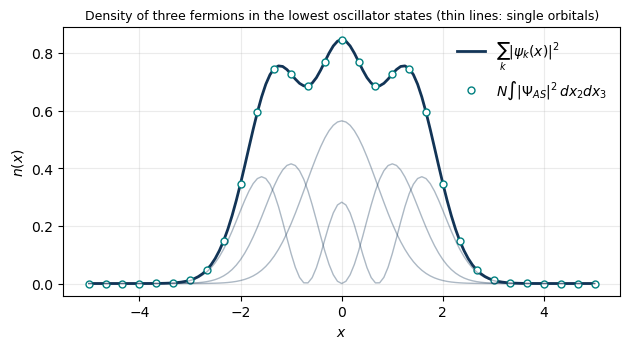

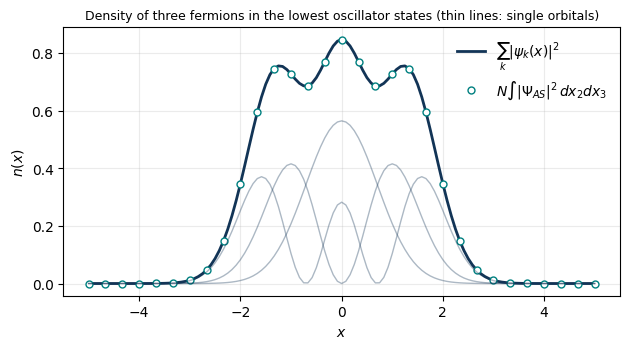

In [14]:
import matplotlib.pyplot as plt
from numpy.polynomial.hermite import hermval

def ho_orbital(k, x):
    coeff = np.zeros(k + 1); coeff[k] = 1.0
    return hermval(x, coeff) * np.exp(-x**2 / 2) / np.sqrt(2.0**k * factorial(k) * np.sqrt(np.pi))

N3 = 3
x = np.linspace(-5, 5, 121)
dx = x[1] - x[0]
phi = np.array([ho_orbital(k, x) for k in range(N3)])          # (N, grid)
print("orbitals orthonormal on the grid:", np.allclose(phi @ phi.T * dx, np.eye(N3), atol=1e-6))

# determinant on the 3D grid: matrix [psi_k(x_j)] at every (x1, x2, x3)
X1, X2, X3 = np.meshgrid(x, x, x, indexing="ij")
M = np.stack([np.stack([ho_orbital(k, X) for k in range(N3)], axis=-1) for X in (X1, X2, X3)], axis=-2)  # (...,3 coords,3 orbitals)
Psi = np.linalg.det(M) / np.sqrt(factorial(N3))
density_bruteforce = N3 * np.sum(np.abs(Psi)**2, axis=(1, 2)) * dx**2
density_formula = np.sum(np.abs(phi)**2, axis=0)

print("n(x) = sum_k |psi_k(x)|^2 on the grid   :", np.allclose(density_bruteforce, density_formula, atol=1e-6))
print("integral of n(x) dx = N                 :", np.sum(density_bruteforce) * dx)

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(x, density_formula, color="#123456", lw=2.0, label=r"$\sum_k |\psi_k(x)|^2$")
ax.plot(x[::4], density_bruteforce[::4], "o", ms=5, mfc="white", color="#008080", label=r"$N\int |\Psi_{AS}|^2\, dx_2 dx_3$")
for k in range(N3):
    ax.plot(x, np.abs(phi[k])**2, color="#123456", lw=1.0, alpha=0.35)
ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$n(x)$")
ax.set_title("Density of three fermions in the lowest oscillator states (thin lines: single orbitals)", fontsize=9)
ax.grid(alpha=0.25); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

### Exercise 2b: the same matrix elements from second quantization

$\langle\alpha_1\alpha_2|\hat F|\alpha_1\alpha_2\rangle=\langle\alpha_1|f|\alpha_1\rangle+\langle\alpha_2|f|\alpha_2\rangle$ and $\langle\alpha_1\alpha_2|\hat G|\alpha_1\alpha_2\rangle=\langle\alpha_1\alpha_2|g|\alpha_1\alpha_2\rangle-\langle\alpha_1\alpha_2|g|\alpha_2\alpha_1\rangle$ -- application 1 and 2 of Friday's lecture, and exercise 1c) of week 35 in first quantization.

In [15]:
ok_F = ok_G = True
for (a1, a2) in combinations(range(n6), 2):
    ket = S.determinant((a1, a2))
    ok_F &= np.isclose(ket @ F6 @ ket, f6[a1, a1] + f6[a2, a2])
    ok_G &= np.isclose(ket @ G6 @ ket, g6[a1, a2, a1, a2] - g6[a1, a2, a2, a1])
print("2b) <a1a2|F|a1a2> = f_a1a1 + f_a2a2                       :", ok_F)
print("    <a1a2|G|a1a2> = <a1a2|g|a1a2> - <a1a2|g|a2a1>          :", ok_G)

2b) <a1a2|F|a1a2> = f_a1a1 + f_a2a2                       : True
    <a1a2|G|a1a2> = <a1a2|g|a1a2> - <a1a2|g|a2a1>          : True


## Where to go from here

* Change `holes`/`parts` in section 9 (the Fermi level) and re-run: every identity must survive. Try $n_c=0$ -- the particle-hole forms collapse to the ordinary ones -- and $n_c=n$.
* Replace the random matrix elements by those of a physical model (the pairing model of week 35, or the harmonic-oscillator elements of exercise 2a) and compute $E_{\rm ref}$ as a function of which orbitals are filled.
* Next week the particle-hole form of $\hat H$ is written compactly as $E_{\rm ref}+\hat F_N+\hat V_N$; the one-body pieces of the five groups assembled in section 9 are the Fock operator.